In [25]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import nltk
from nltk.corpus import stopwords
import string 
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import re 

In [3]:
campaigns

,Unnamed: 0,url,title,description,pledged,goal,currency,reached,status,description_processed,stemmed,lemmatized,category
0,0,https://www.kickstarter.com/projects/thetruthb...,NaN,The PROBLEM: So much entertainment today pushe...,71123.0,48000.0,USD,148.172917,1,"['problem', 'much', 'entertainment', 'today', ...","['problem', 'much', 'entertain', 'today', 'pus...","['problem', 'much', 'entertainment', 'today', ...",Film & Video
1,1,https://www.kickstarter.com/projects/99625582/...,NaN,Millions of American college students have stu...,65318.0,61500.0,USD,106.208130,1,"['millions', 'american', 'college', 'students'...","['million', 'american', 'colleg', 'student', '...","['million', 'american', 'college', 'student', ...",Film & Video
2,2,https://www.kickstarter.com/projects/distortre...,Cartoon Network Alphabet Pins,Full A-Z Set I'm launching this set to show my...,462.0,8000.0,USD,5.775000,0,"['full', 'az', 'set', 'im', 'launching', 'set'...","['full', 'az', 'set', 'im', 'launch', 'set', '...","['full', 'az', 'set', 'im', 'launching', 'set'...",Film & Video
3,3,https://www.kickstarter.com/projects/jordym/th...,The Balloon - a short film,"On a sleepy summer afternoon, we stared into t...",5137.0,15000.0,USD,34.246667,0,"['sleepy', 'summer', 'afternoon', 'stared', 'v...","['sleepi', 'summer', 'afternoon', 'stare', 'vo...","['sleepy', 'summer', 'afternoon', 'stared', 'v...",Film & Video
4,4,https://www.kickstarter.com/projects/trans-mov...,NaN,48 hours of pledge matching! Amazing news! Two...,50640.0,50000.0,USD,101.280000,0,"['48', 'hours', 'pledge', 'matching', 'amazing...","['48', 'hour', 'pledg', 'match', 'amaz', 'news...","['48', 'hour', 'pledge', 'matching', 'amazing'...",Film & Video
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7349,7349,https://www.kickstarter.com/projects/zerwcolla...,ZerwCollab: Your AI-Powered App Builder in Sec...,🚀 What If You Could Launch a Website or App… U...,2128.0,35900.0,USD,5.927577,0,"['🚀', 'could', 'launch', 'website', 'app…', 'u...","['🚀', 'could', 'launch', 'websit', 'app…', 'us...","['🚀', 'could', 'launch', 'website', 'app…', 'u...",Technology
7350,7350,https://www.kickstarter.com/projects/jacobzirk...,VFX Oasis: Free VFX Assets and Footage,What is VFX Oasis? VFX Oasis is an industry fo...,580.0,6000.0,USD,9.666667,0,"['vfx', 'oasis', 'vfx', 'oasis', 'industry', '...","['vfx', 'oasi', 'vfx', 'oasi', 'industri', 'fo...","['vfx', 'oasis', 'vfx', 'oasis', 'industry', '...",Technology
7351,7351,https://www.kickstarter.com/projects/153189407...,Sharp X - Edge Gadget,Kickstarter Project Story – USA-Market Sharpen...,857.0,7800.0,USD,10.987179,0,"['kickstarter', 'project', 'story', '–', 'usam...","['kickstart', 'project', 'stori', '–', 'usamar...","['kickstarter', 'project', 'story', '–', 'usam...",Technology
7352,7352,https://www.kickstarter.com/projects/diyengine...,Steady Shot Bot: Hyperlapse + Steadycam + Auto...,"Why As a hobbyist, I recently found myself wan...",6645.0,310000.0,USD,2.143548,0,"['hobbyist', 'recently', 'found', 'wanting', '...","['hobbyist', 'recent', 'found', 'want', 'photo...","['hobbyist', 'recently', 'found', 'wanting', '...",Technology


In [8]:
campaigns = pd.read_csv('Kickstarter_dataset_14-04.csv')
campaigns = campaigns.drop(columns = ['Unnamed: 0', 'description_processed', 'stemmed', 'lemmatized'])
campaigns['reached'] = (campaigns['pledged'] / campaigns['goal']) * 100
campaigns

,url,title,description,pledged,goal,currency,reached,status,category
0,https://www.kickstarter.com/projects/thetruthb...,NaN,The PROBLEM: So much entertainment today pushe...,71123.0,48000.0,USD,148.172917,1,Film & Video
1,https://www.kickstarter.com/projects/99625582/...,NaN,Millions of American college students have stu...,65318.0,61500.0,USD,106.208130,1,Film & Video
2,https://www.kickstarter.com/projects/distortre...,Cartoon Network Alphabet Pins,Full A-Z Set I'm launching this set to show my...,462.0,8000.0,USD,5.775000,0,Film & Video
3,https://www.kickstarter.com/projects/jordym/th...,The Balloon - a short film,"On a sleepy summer afternoon, we stared into t...",5137.0,15000.0,USD,34.246667,0,Film & Video
4,https://www.kickstarter.com/projects/trans-mov...,NaN,48 hours of pledge matching! Amazing news! Two...,50640.0,50000.0,USD,101.280000,0,Film & Video
...,...,...,...,...,...,...,...,...,...
7349,https://www.kickstarter.com/projects/zerwcolla...,ZerwCollab: Your AI-Powered App Builder in Sec...,🚀 What If You Could Launch a Website or App… U...,2128.0,35900.0,USD,5.927577,0,Technology
7350,https://www.kickstarter.com/projects/jacobzirk...,VFX Oasis: Free VFX Assets and Footage,What is VFX Oasis? VFX Oasis is an industry fo...,580.0,6000.0,USD,9.666667,0,Technology
7351,https://www.kickstarter.com/projects/153189407...,Sharp X - Edge Gadget,Kickstarter Project Story – USA-Market Sharpen...,857.0,7800.0,USD,10.987179,0,Technology
7352,https://www.kickstarter.com/projects/diyengine...,Steady Shot Bot: Hyperlapse + Steadycam + Auto...,"Why As a hobbyist, I recently found myself wan...",6645.0,310000.0,USD,2.143548,0,Technology


In [9]:
avg_goal = campaigns['goal'].mean()
print('avg goal: ', avg_goal, 'USD')
high_goal = campaigns['goal'].max()
print('highest goal: ', high_goal, 'USD')
low_goal = campaigns['goal'].min()
print('lowest goal: ', low_goal, 'USD')

avg_reached = campaigns['reached'].mean()                  
print('avg fund rate: ', avg_reached, '%')
high_reached = campaigns['reached'].max()
print('highest fund rate: ', high_reached, '%')
low_reached = campaigns['reached'].min()
print('lowest fund rate: ', low_reached, '%')
median_reached = campaigns['reached'].median()
print('median fund rate: ', median_reached, '%')




avg goal:  24875.763574925208 USD
highest goal:  1000000.0 USD
lowest goal:  5001.0 USD
avg fund rate:  235.71959652262862 %
highest fund rate:  41290.95 %
lowest fund rate:  0.2 %
median fund rate:  102.68847826086957 %


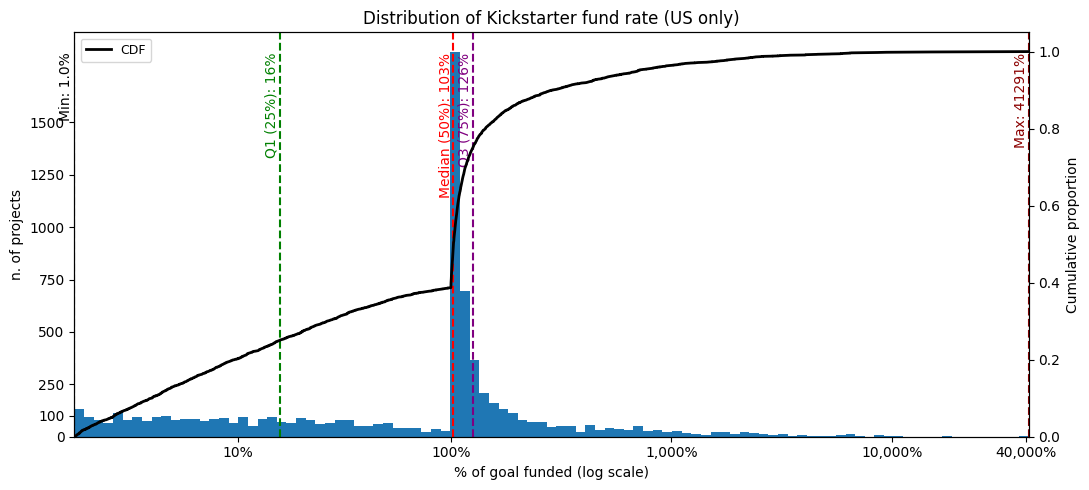

In [10]:
fund_rates = campaigns[campaigns['reached'] > low_reached]['reached']
fig, ax = plt.subplots(figsize=(11, 5))
quartiles = [fund_rates.quantile(q) for q in [0.25, 0.5, 0.75]]
q_labels = ['Q1 (25%)', 'Median (50%)', 'Q3 (75%)']
colors = ['green', 'red', 'purple']

ax.hist(np.log1p(fund_rates), bins=np.linspace(np.log1p(fund_rates.min()), np.log1p(fund_rates.max()), 100))

# collect all lines to draw and annotate together
lines = []
for q, label, color in zip(quartiles, q_labels, colors):
    lines.append((np.log1p(q), color, f'{label}: {q:.0f}%'))

lines.append((np.log1p(fund_rates.max()), 'darkred', f'Max: {fund_rates.max():.0f}%'))
lines.append((np.log1p(fund_rates.min()), 'black', f'Min: {fund_rates.min():.1f}%'))

y_top = ax.get_ylim()[1]
for x_pos, color, text in lines:
    ax.axvline(x_pos, color=color, linestyle='--', linewidth=1.5)
    ax.text(x_pos - 0.01, y_top * 0.95, text, color=color, fontsize=10, ha='right', rotation=90, va='top')

ax.set_title('Distribution of Kickstarter fund rate (US only)')
ax.set_xlabel('% of goal funded (log scale)')
ax.set_ylabel('n. of projects')
ax.set_yticks([0, 100, 250, 500, 750, 1000, 1250, 1500])

ticks = np.log1p([0.5, 1, 10, 100, 1000, 10000, 40000])
ax.set_xticks(ticks)
ax.set_xticklabels(['0.5%', '1%', '10%', '100%', '1,000%', '10,000%', '40,000%'])
ax.set_xlim(np.log1p(fund_rates.min()), np.log1p(fund_rates.max()))

ax2 = ax.twinx()
x = np.sort(fund_rates.values)
y = np.arange(1, len(x) + 1) / len(x)
ax2.plot(np.log1p(x), y, color='black', linewidth=2, label='CDF')
ax2.set_ylabel('Cumulative proportion')
ax2.set_ylim(0, 1.05)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

In [36]:
campaigns['status'] = campaigns['reached'].apply(lambda x: 1 if x >= median_reached else 0)
campaigns['status'].value_counts()

status
1    3677
0    3677
Name: count, dtype: int64

In [37]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text_p = "".join([char for char in text if char.isalnum() or char.isspace()])
    
    words = word_tokenize(text_p) 
    
    
    stop_words = stopwords.words('english')
    words = [w for w in words if w not in stop_words and len(w) > 2]
    filtered_words = [word for word in words if word not in stop_words] 
    
    return filtered_words  

campaigns['description_processed'] = campaigns['description'].apply(preprocess)

How do we decide which stopwords to include beside the 'normal' stopwords? We also want to include words that are very generic, not informative at all and coudl potentially appear in any kind of campaign, regardless of the topics in it (some examples could be the words 'kickstarter', campaign, etc etc)
Initially I thought TF-IDF would make sense but it doesn't actually, because TF-IDF both depends on how frequent a word is in each document and how frequent are documents that contain that words in the whole set of documents. (also you cannot average the TF-IDF of a word and pick the ones with lowest value because a rare word, which we wanna keep, could end up having a low TF-IDF value if it appears in few documents but many time in those few documents)
So potentially we can just use document frequency, meaning if the word appears in > alpha% of documents, we count it as a stopword?

Also quick sidenote: Other methods like BytePair encoding, WordPiece or SentencePiece are not really useful here because they look at subwords, and for example if we get 'kickstarter' and split it into kick and starter, then we might consider to keep kick because it makes sense with sport but we might not have any document where the word is present for real

In [30]:
from collections import Counter

docs = campaigns['description_processed']
N = len(docs)

df_counter = Counter()

for doc in docs:
    df_counter.update(set(doc))

df_table = pd.DataFrame({
    'word': list(df_counter.keys()),
    'doc_freq': list(df_counter.values())
})

df_table['doc_freq_ratio'] = df_table['doc_freq'] / N
df_table = df_table.sort_values('doc_freq_ratio', ascending=False)

print(df_counter)
df_table

Counter({'one': 5050, 'time': 4908, 'make': 4887, 'help': 4712, 'new': 4693, 'also': 4677, 'like': 4649, 'first': 4512, 'project': 4439, 'get': 4308, 'world': 4217, 'need': 4121, 'kickstarter': 4005, 'support': 3955, 'work': 3913, 'years': 3902, 'well': 3849, 'life': 3834, 'way': 3783, 'many': 3661, 'people': 3658, 'want': 3637, 'every': 3567, 'see': 3462, 'love': 3395, 'goal': 3391, 'even': 3376, 'two': 3178, 'campaign': 3172, 'create': 3135, 'experience': 3134, 'back': 3120, 'bring': 3069, 'story': 3061, 'take': 3016, 'production': 3011, 'made': 3006, 'making': 3001, 'much': 2977, 'best': 2966, 'would': 2962, 'team': 2937, 'together': 2898, 'design': 2887, 'know': 2803, 'part': 2765, 'use': 2752, 'come': 2729, 'around': 2722, 'set': 2719, 'music': 2633, 'thank': 2573, 'rewards': 2572, 'working': 2571, 'full': 2529, 'friends': 2516, 'right': 2500, 'something': 2493, 'including': 2485, 'find': 2478, 'without': 2462, 'great': 2448, 'share': 2443, 'play': 2428, 'dont': 2415, 'art': 2408,

,word,doc_freq,doc_freq_ratio
320,one,5050,0.686701
315,time,4908,0.667392
439,make,4887,0.664536
335,help,4712,0.640740
630,new,4693,0.638156
...,...,...,...
129028,16vdc16a,1,0.000136
129027,48vdc14a,1,0.000136
129026,881,1,0.000136
129025,118db,1,0.000136


In [33]:
min_ratio = 0.0005
max_ratio = 0.55     
vocab = set(
    df_table[
        (df_table['doc_freq_ratio'] > min_ratio) &
        (df_table['doc_freq_ratio'] < max_ratio)
    ]['word']
)
campaigns['description_filtered'] = campaigns['description_processed'].apply(
    lambda doc: [w for w in doc if w in vocab]
)
print(df_table[df_table['doc_freq_ratio'] >= max_ratio])
print(df_table[df_table['doc_freq_ratio'] <= min_ratio])

         word  doc_freq  doc_freq_ratio
320       one      5050        0.686701
315      time      4908        0.667392
439      make      4887        0.664536
335      help      4712        0.640740
630       new      4693        0.638156
22       also      4677        0.635980
305      like      4649        0.632173
338     first      4512        0.613544
1222  project      4439        0.603617
432       get      4308        0.585804
206     world      4217        0.573429
1137     need      4121        0.560375
               word  doc_freq  doc_freq_ratio
54665     sailboats         3        0.000408
123771  catholicand         3        0.000408
123770          xvi         3        0.000408
123769        setto         3        0.000408
123768     jernberg         3        0.000408
...             ...       ...             ...
129028     16vdc16a         1        0.000136
129027     48vdc14a         1        0.000136
129026          881         1        0.000136
129025        118db 

In [ ]:
campaigns['description_processed']

In [34]:
# remove tokens with digits or weird artifacts
campaigns['description_processed'] = campaigns['description_processed'].apply(
    lambda doc: [w for w in doc if w.isalpha() and len(w) > 2]
)
campaigns['description_processed']

0       [problem, much, entertainment, today, pushes, ...
1       [millions, american, college, students, studie...
2       [full, set, launching, set, show, love, early,...
3       [sleepy, summer, afternoon, stared, void, floa...
4       [hours, pledge, matching, amazing, news, two, ...
                              ...                        
7349    [could, launch, website, app, using, voice, im...
7350    [vfx, oasis, vfx, oasis, industry, focused, vi...
7351    [kickstarter, project, story, usamarket, sharp...
7352    [hobbyist, recently, found, wanting, photograp...
7353    [brilliant, buds, introduces, covert, wireless...
Name: description_processed, Length: 7354, dtype: object

In [10]:
porter = PorterStemmer()
lemmatizer = WordNetLemmatizer()

campaigns['stemmed'] = campaigns['description_processed'].apply(
    lambda words: [porter.stem(word) for word in words]
)

campaigns['lemmatized'] = campaigns['description_processed'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

In [11]:
campaigns['stemmed']

0       [problem, much, entertain, today, push, unholi...
1       [million, american, colleg, student, studi, ab...
2       [full, az, set, im, launch, set, show, love, e...
3       [sleepi, summer, afternoon, stare, void, float...
4       [48, hour, pledg, match, amaz, news, two, gene...
                              ...                        
7349    [🚀, could, launch, websit, app…, use, voic, im...
7350    [vfx, oasi, vfx, oasi, industri, focus, visual...
7351    [kickstart, project, stori, –, usamarket, shar...
7352    [hobbyist, recent, found, want, photographi, t...
7353    [brilliant, bud, introduc, covert, wireless, d...
Name: stemmed, Length: 7354, dtype: object

In [12]:
campaigns['lemmatized']

0       [problem, much, entertainment, today, push, un...
1       [million, american, college, student, studied,...
2       [full, az, set, im, launching, set, show, love...
3       [sleepy, summer, afternoon, stared, void, floa...
4       [48, hour, pledge, matching, amazing, news, tw...
                              ...                        
7349    [🚀, could, launch, website, app…, using, voice...
7350    [vfx, oasis, vfx, oasis, industry, focused, vi...
7351    [kickstarter, project, story, –, usamarket, sh...
7352    [hobbyist, recently, found, wanting, photograp...
7353    [brilliant, bud, introduces, covert, wireless,...
Name: lemmatized, Length: 7354, dtype: object

In [13]:
import pandas as pd
import glob


folder_path = "Kickstarter_2026-03-12T03_20_26_556Z"

files = glob.glob(f"{folder_path}/*.csv")

print("Number of files found:", len(files))

dfs = []

for file in files:
    print("Loading:", file)
    df_temp = pd.read_csv(file)
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

print("Final shape:", df.shape)

Number of files found: 85
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter001.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter002.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter003.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter004.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter005.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter006.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter007.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter008.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter009.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter010.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter011.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter012.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter013.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter014.csv
Lo

In [14]:
import ast

url_to_category = {}
for _, row in df.iterrows():
    parsed = ast.literal_eval(row['category'])
    parent_name = parsed.get('parent_name') or parsed.get('name')
    url_parsed = ast.literal_eval(row['urls'])
    project_url = url_parsed['web']['project']
    url_to_category[project_url] = parent_name


campaigns['category'] = campaigns['url'].map(url_to_category)

print(f"Matched: {campaigns['category'].notna().sum()} / {len(campaigns)}")
print(campaigns['category'].value_counts())

Matched: 7354 / 7354
category
Film & Video    2011
Technology      1489
Games           1422
Music           1218
Publishing      1214
Name: count, dtype: int64


In [17]:
campaigns.to_csv('Kickstarter_dataset_14-04.csv')